In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import corner

from bilby.gw.conversion import lambda_1_lambda_2_to_lambda_tilde, lambda_1_lambda_2_to_delta_lambda_tilde, lambda_tilde_delta_lambda_tilde_to_lambda_1_lambda_2

In [2]:
narrow_df = pd.read_csv("../../events/gw/gw_params_narrow.dat", sep=" ")
detection_df = pd.read_csv("../../events/detection/detection_output/narrow_ETL.dat", sep=" ")
events = pd.read_csv("events.dat", sep=" ")
events["mass_ratio"] = events["mass_2"] / events["mass_1"]


In [8]:
np.sort(events["mass_2_source"])

array([1.14592381, 1.1623686 , 1.17282631, 1.17711077, 1.17941777,
       1.18224338, 1.18791427, 1.18939772, 1.19558548, 1.19813624,
       1.19839546, 1.20449553, 1.20573611, 1.20796385, 1.21533354,
       1.21584917, 1.21775789, 1.22492818, 1.22702906, 1.23415899,
       1.24885465, 1.24908125, 1.24979708, 1.25325399, 1.25421232,
       1.25897373, 1.25906301, 1.2632302 , 1.26772932, 1.26888713,
       1.27067273, 1.27301957, 1.273234  , 1.27365128, 1.27976947,
       1.29206259, 1.2925644 , 1.29463015, 1.30090466, 1.3049679 ,
       1.30510973, 1.30692612, 1.30716507, 1.30944117, 1.31161813,
       1.31266577, 1.31399229, 1.31922965, 1.31971409, 1.32252293,
       1.32331405, 1.32436149, 1.32719176, 1.32781003, 1.32851671,
       1.32860359, 1.33439237, 1.33507282, 1.33734782, 1.33767993,
       1.34111347, 1.34265779, 1.34388945, 1.35220362, 1.352421  ,
       1.35310893, 1.36123319, 1.36132746, 1.36195155, 1.36229987,
       1.36396586, 1.36485908, 1.36580717, 1.36644723, 1.37265

In [3]:
n_coll = np.sum(events["prompt_collapse"] ==1 )
n_tot = events.shape[0]
pop_coll_share = np.sum(narrow_df["prompt_collapse"]==1)/narrow_df.shape[0]

print(f"Prompt collapse: {n_coll}/{n_tot}, {n_coll/n_tot:.3f}, ", pop_coll_share)

Prompt collapse: 2/78, 0.026,  0.12467130703789636


In [4]:
log10_mej_wind = events["log10_mej_wind"]
zeta = 10**(events["log10_mej_wind"] - events["log10_mdisk"])

print("wind quantile: ", np.quantile(log10_mej_wind, 0.05))
print("zeta quantile: ", np.quantile(zeta, 0.05))

wind quantile:  -1.820405449437789
zeta quantile:  0.13210762219043795


In [5]:
print("SNR min max: ", np.min(events["snr"]), np.max(events["snr"]))

SNR min max:  13.101 362.829


In [6]:
events["log10_mej_wind"].min()

np.float64(-2.184452290012422)

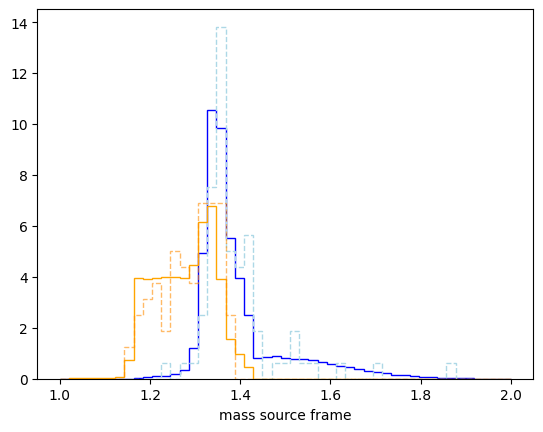

In [7]:
bins = np.linspace(1, 2, 50)

plt.hist(narrow_df["mass_1_source"], bins=bins, density=True, histtype="step", color="blue")
plt.hist(events["mass_1_source"], bins=bins, density=True, histtype="step", color="lightblue", linestyle="dashed")

plt.hist(narrow_df["mass_2_source"], bins=bins, density=True, color="orange", histtype="step")
plt.hist(events["mass_2_source"], bins=bins, density=True, histtype="step", alpha=0.6, color="darkorange", linestyle="dashed")


plt.xlabel("mass source frame")
plt.show()

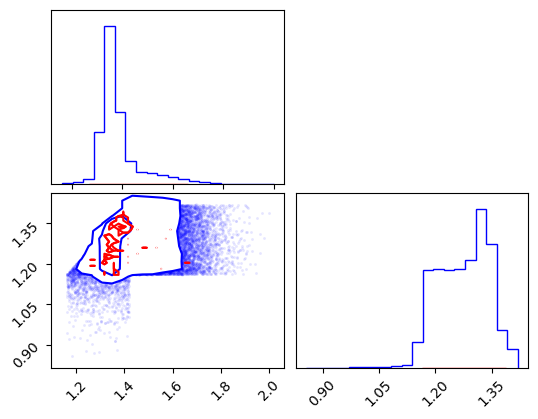

In [8]:
fig, ax = plt.subplots(2,2)

corner.corner(np.array([narrow_df["mass_1_source"], narrow_df["mass_2_source"]]).T,
                       color="blue", fig=fig, plot_density=False, levels=[0.68, 0.95])

corner.corner(np.array([events["mass_1_source"], events["mass_2_source"]]).T,
                       color="red", fig=fig, plot_density=False, levels=[0.68, 0.95])

fig.show()

(array([ 3., 11., 10., 16., 14., 24.,  4.,  1.,  1.,  1.]),
 array([0.17679755, 0.18226986, 0.18774218, 0.19321449, 0.19868681,
        0.20415912, 0.20963143, 0.21510375, 0.22057606, 0.22604838,
        0.23152069]),
 [<matplotlib.patches.Polygon at 0x7f1310630850>])

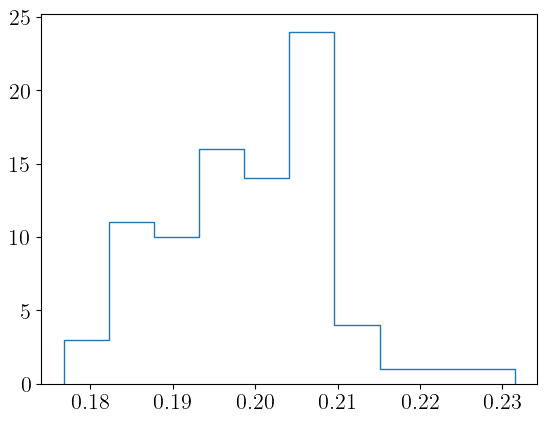

In [41]:
plt.hist(events.loc[:, "v_ej_dyn"], histtype="step")


(array([ 3., 11., 10., 16., 14., 24.,  4.,  1.,  1.,  1.]),
 array([0.17679755, 0.18226986, 0.18774218, 0.19321449, 0.19868681,
        0.20415912, 0.20963143, 0.21510375, 0.22057606, 0.22604838,
        0.23152069]),
 [<matplotlib.patches.Polygon at 0x7f13b661f510>])

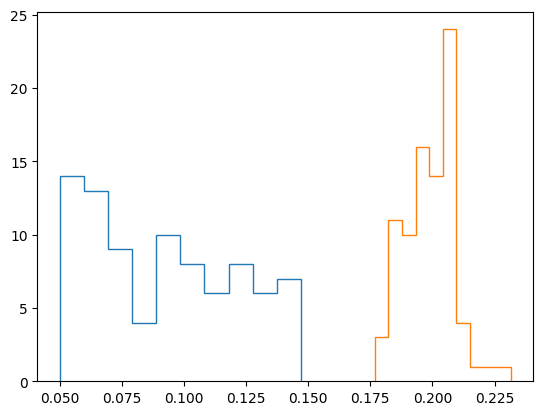

In [10]:
plt.hist(events.loc[:, "v_ej_wind"], histtype="step")
plt.hist(events.loc[:, "v_ej_dyn"], histtype="step")


In [42]:
events["v_ej_dyn"].min()

np.float64(0.1767975505358664)

(array([5.35926089e-03, 4.63576067e-02, 1.92397466e-01, 4.79921813e-01,
        8.37652477e-01, 1.14205850e+00, 2.35566312e+00, 4.70864662e+00,
        6.27810617e+00, 8.20717213e+00]),
 array([0.58767796, 0.62890941, 0.67014085, 0.71137229, 0.75260373,
        0.79383518, 0.83506662, 0.87629806, 0.9175295 , 0.95876095,
        0.99999239]),
 [<matplotlib.patches.Polygon at 0x7f357b95d550>])

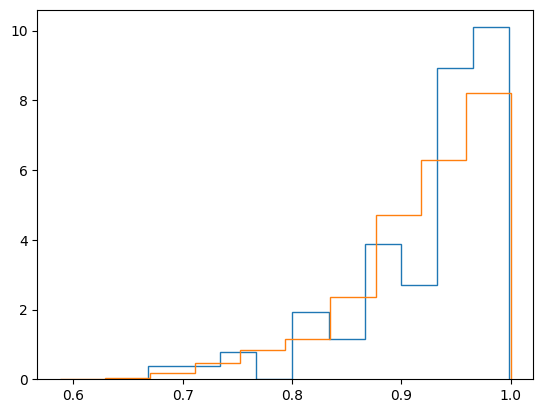

In [9]:
plt.hist(events["mass_ratio"], density=True, histtype="step")
plt.hist(narrow_df["mass_2"] / narrow_df["mass_1"], density=True, histtype="step")

(array([9.83281365e-04, 1.37659391e-02, 1.01769621e-01, 1.88478650e+00,
        3.28924005e+00, 1.59193253e+00, 3.94459708e-01, 1.19632566e-01,
        1.84365256e-02, 1.39298193e-03]),
 array([2.03970241, 2.17453872, 2.30937504, 2.44421135, 2.57904767,
        2.71388398, 2.84872029, 2.98355661, 3.11839292, 3.25322924,
        3.38806555]),
 [<matplotlib.patches.Polygon at 0x7f8455b1f010>])

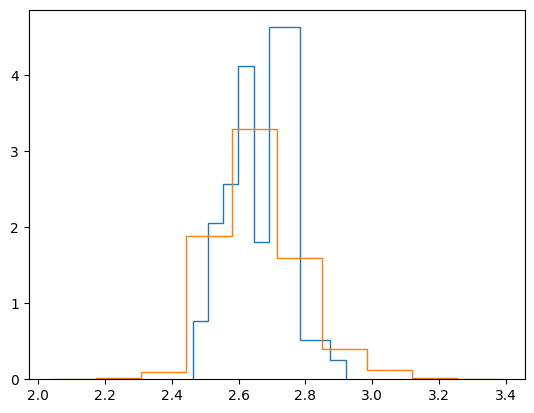

In [13]:
plt.hist(events["mass_2_source"] + events["mass_1_source"], density=True, histtype="step")
plt.hist(narrow_df["mass_2_source"] + narrow_df["mass_1_source"], density=True, histtype="step")

(array([0.08257902, 0.22965637, 0.35407119, 0.44736468, 0.49127994,
        0.49272498, 0.43724937, 0.35297859, 0.22391143, 0.07820864]),
 array([0.0053703 , 0.31884755, 0.63232479, 0.94580204, 1.25927928,
        1.57275653, 1.88623377, 2.19971102, 2.51318827, 2.82666551,
        3.14014276]),
 [<matplotlib.patches.Polygon at 0x7f357b9a6f50>])

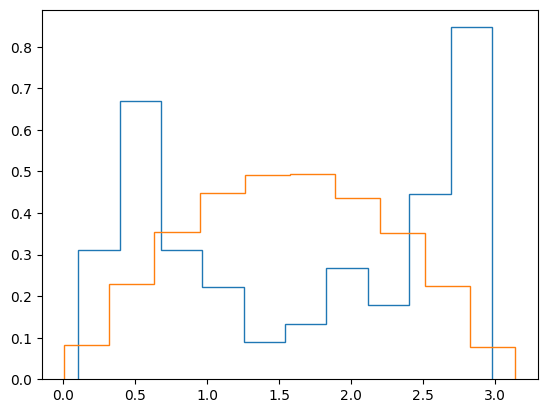

In [10]:
plt.hist((events["theta_jn"]), histtype="step", density=True)
plt.hist((narrow_df["theta_jn"]), histtype="step", density=True)

In [12]:
events["luminosity_distance"].max()

np.float64(4207.650166856365)

Text(0, 0.5, '$d_L$')

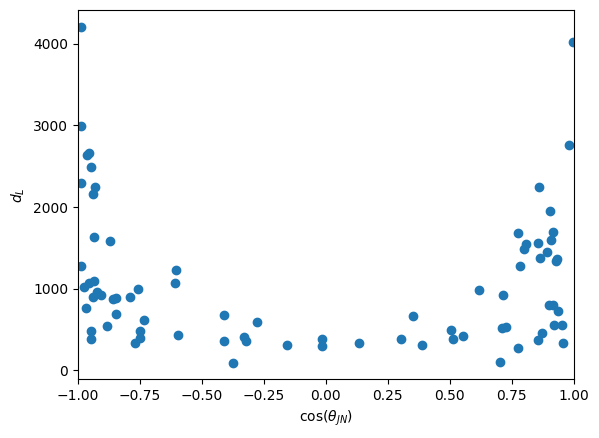

In [13]:
plt.scatter(np.cos(events["theta_jn"]), events["luminosity_distance"])
plt.ylabel("$d_L$")
plt.xlabel("$\\cos(\\theta_{JN})$")

plt.xlim((-1, 1))
plt.ylabel("$d_L$")

In [14]:
events.loc[[15, 77], "thetaCore"]

15    0.054787
77    0.099271
Name: thetaCore, dtype: float64

In [17]:
np.pi/5

0.6283185307179586

(array([ 6., 21., 12.,  5.,  5.,  9.,  7.,  8.,  3.,  2.]),
 array([0.01499786, 0.05862156, 0.10224526, 0.14586896, 0.18949266,
        0.23311635, 0.27674005, 0.32036375, 0.36398745, 0.40761115,
        0.45123485]),
 <BarContainer object of 10 artists>)

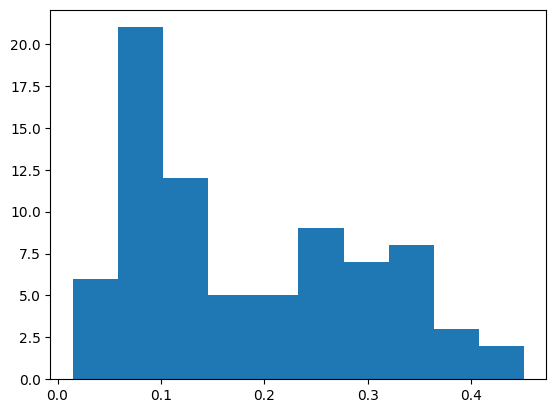

In [16]:
plt.hist(events["thetaCore"])

In [11]:
from fiesta.inference.lightcurve_model import FluxModel

from matplotlib.colors import LinearSegmentedColormap
model_KN = FluxModel("Bu2026_MLP", filters=["lssti", "lsstg"])

cmap = LinearSegmentedColormap.from_list("cmap", ["lightgreen", "darkgreen"])

/home/koehn1/miniconda3/envs/nmma_x_fiesta/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
14:48 fiesta INFO    : Loading surrogate Bu2026_MLP. This surrogate should only be used in the following parameter ranges:
14:48 fiesta INFO    : 	 log10_mej_dyn: (-4.0, -1.3010299956639813)
14:48 fiesta INFO    : 	 v_ej_dyn: (0.12, 0.35)
14:48 fiesta INFO    : 	 Ye_dyn: (0.15, 0.35)
14:48 fiesta INFO    : 	 log10_mej_wind: (-4.0, -0.5502131530142267)
14:48 fiesta INFO    : 	 v_ej_wind: (0.05, 0.15)
14:48 fiesta INFO    : 	 Ye_wind: (0.2, 0.4)
14:48 fiesta INFO    : 	 inclination_EM: (0.0, 1.5707963267948966)
14:48 fiesta INFO    : Surrogate Bu2026_MLP is loading with source-frame time range [ 0.19405578 27.52765949] days.
14:48 fiesta INFO    : Surrogate Bu2026_MLP is loading with the following filters: ['lssti',

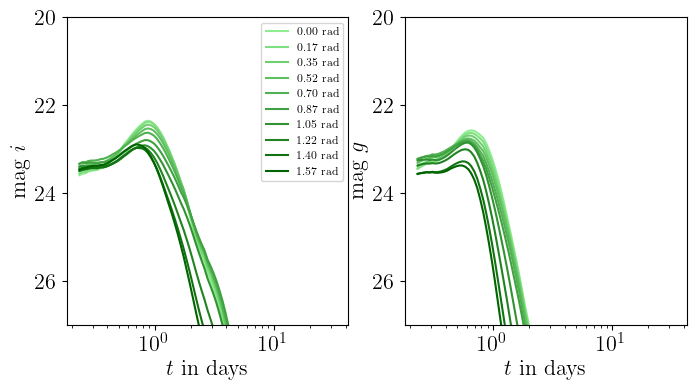

In [13]:
params = dict(log10_mej_dyn=-2.3, v_ej_dyn=0.2, Ye_dyn=0.25, log10_mej_wind=-1.16, v_ej_wind=0.1, Ye_wind=0.29, luminosity_distance=1000, redshift=0.2)

magg_peak = []
magi_peak = []
fig, ax = plt.subplots(1,2, figsize=(8,4))
for incl in np.linspace(0, np.pi/2, 10):

    params["inclination_EM"] = incl
    times, mags = model_KN.predict(params)

    ax[0].plot(times, mags["lssti"], color=cmap(incl/(np.pi/2)), label=f"${incl:.2f}$ rad")

    ax[1].plot(times, mags["lsstg"], color=cmap(incl/(np.pi/2)))

    magg_peak.append(mags["lsstg"].min())
    magi_peak.append(mags["lssti"].min())


ax[0].set_xscale("log")
ax[1].set_xscale("log")
ax[0].invert_yaxis()
ax[1].set_ylim((27, 20))
ax[0].set_ylim((27, 20))
ax[0].set_xlabel("$t$ in days")
ax[1].set_xlabel("$t$ in days")
ax[0].set_ylabel("mag $i$")
ax[1].set_ylabel("mag $g$")
ax[0].legend(fontsize=8)

In [15]:
magg_peak[-1] - magg_peak[0]

Array(0.79901695, dtype=float32)

In [16]:
magi_peak[-1] - magi_peak[0]

Array(0.5390835, dtype=float32)

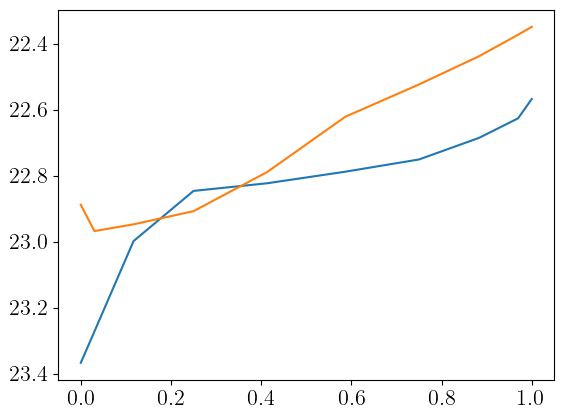

In [21]:
plt.plot(np.cos(np.linspace(0, np.pi/2, 10))**2, magg_peak)
plt.plot(np.cos(np.linspace(0, np.pi/2, 10))**2, magi_peak)

plt.gca().invert_yaxis()